## Sommaire
Navigation rapide vers les sections du notebook.

- [Partie 1 - Regression logistique multiclasse basique](#partie-1---regression-logistique-multiclasse-basique)
- [Partie 2 - Limitation de l eparpillement des classes](#partie-2---limitation-de-l-eparpillement-des-classes)
- [Partie 3 - Regression logistique avec balanced](#partie-3---regression-logistique-avec-balanced)
- [Partie 4 - Regression logistique avec CV en 5 folds](#partie-4---regression-logistique-avec-cv-en-5-folds)
- [Partie 5 - RN basique sans optimisation](#partie-5---rn-basique-sans-optimisation)

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier



In [2]:
df = pd.read_csv(r"c:\Users\AsgharAli Thomas\Documents\RFID2\ds_Tx(1).csv")
df.shape

(4411, 64)

In [3]:
import numpy as np
import pandas as pd

def calculate_localization_errors(y_pred_cv, df, X_test, Nx, Ny, h, voxel_center, random_seed=42):
    """
    Calcule les erreurs de localisation (RMSE, moyenne, médiane, max)
    entre les coordonnées prédites et réelles.
    """
    np.random.seed(random_seed)

    true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy()

    errors = []
    pred_coords = []
    true_coords_list = []

    for pred_id, true_xyz in zip(y_pred_cv, true_coords):
        pred_xyz = voxel_center(pred_id, Nx, Ny, h)
        err = np.linalg.norm(true_xyz - pred_xyz)

        errors.append(err)
        pred_coords.append(pred_xyz)
        true_coords_list.append(true_xyz)

    errors = np.array(errors)
    rmse = float(np.sqrt(np.mean(errors ** 2)))

    return {
        "mean_error": errors.mean(),
        "rmse": rmse,
        "median_error": np.median(errors),
        "max_error": errors.max(),
        "predicted_coords": np.array(pred_coords),
        "true_coords": np.array(true_coords_list)
    }

def analyze_prediction_errors(y_test, y_pred_cv, xyz_test_cv, predA3_cv, threshold=1.3, random_seed=42):
    """
    Analyse les erreurs de prédiction entre les coordonnées réelles et prédites.
    """
    np.random.seed(random_seed)

    rows_diff = []

    for class_true, class_pred, xyz_true, xyz_pred in zip(
        np.asarray(y_test).astype(int),
        np.asarray(y_pred_cv).astype(int),
        xyz_test_cv,
        predA3_cv
    ):
        dx = float(xyz_pred[0] - xyz_true[0])
        dy = float(xyz_pred[1] - xyz_true[1])
        dz = float(xyz_pred[2] - xyz_true[2])
        dist = float(np.linalg.norm([dx, dy, dz]))

        rows_diff.append({
            "class_id_true": int(class_true),
            "class_id_pred": int(class_pred),
            "x_true": float(xyz_true[0]),
            "y_true": float(xyz_true[1]),
            "z_true": float(xyz_true[2]),
            "x_pred": float(xyz_pred[0]),
            "y_pred": float(xyz_pred[1]),
            "z_pred": float(xyz_pred[2]),
            "dx": dx,
            "dy": dy,
            "dz": dz,
            "distance": dist
        })

    df_diff = pd.DataFrame(rows_diff)
    df_diff_threshold = df_diff[df_diff["distance"] > threshold]

    stats = df_diff_threshold[[
        "class_id_true", "class_id_pred", "dx", "dy", "dz", "distance"
    ]].describe()

    return df_diff, df_diff_threshold, stats

On introduit les variables x, y, z. On fait via str split

In [4]:
if "xyz" in df.columns:
    xyz_split = df["xyz"].astype(str).str.split("__", expand=True)
    if xyz_split.shape[1] >= 3:
        df[["x", "y", "z"]] = xyz_split.iloc[:, :3]

required = ["x", "y", "z"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise KeyError(f"Colonnes manquantes dans df: {missing}")

for c in required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=required).copy()
df = df.reset_index(drop=True)

print("Shape df:", df.shape)
df[["x", "y", "z"]].head()

Shape df: (4411, 64)


,x,y,z
0,1.82,2.51,0.05
1,10.10,3.82,1.29
2,10.34,3.33,0.05
3,10.51,3.26,0.05
4,10.71,3.92,1.57


On veut maintenant, crées des voxels de taille 1 en 3D. x-> i, y-> j, z-> k
ici les classes n'ont pas de sens, mais en baseline on peut tester pour voir les resultats que cela peut donner.


In [5]:
X = df
X.shape[1]

64

In [6]:
import numpy as np
import pandas as pd
### voxels
h = 1  # taille du voxel

for c in ["x", "y", "z"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["x", "y", "z"]).copy()

df["i"] = np.floor(df["x"] / h).astype(int)
df["j"] = np.floor(df["y"] / h).astype(int)
df["k"] = np.floor(df["z"] / h).astype(int)

Nx = df["i"].max() + 1 # nombres de voxels en x, y, z
Ny = df["j"].max() + 1
Nk = df["k"].max() + 1

df["class_id"] = df["i"] + Nx * df["j"] + Nx * Ny * df["k"]
target = df["class_id"]
y=target

### voxels

X = df.drop(columns=[
    # Coordonnées et ground truth
    "i", "j", "k", "x", "y", "z", "xyz", "polar",
    # Distances tag-antenne (leakage)
    "D_041A9F60", "D_041A9F61", "D_0F17B312", "D_0F17B313",
    "PORT_1__NONE", "PORT_2__NONE", "PORT_3__NONE", "PORT_4__NONE",    "D_nearestAnt", "nearestD", "nearestAnt",  "041A9F60__NONE", "041A9F61__NONE", "0F173B12__NONE", "0F173B13__NONE",
    # Autres métadonnées potentiellement liées à la position
    "class_id", "filename", "run_id",  # Si présentes
    # Identifiants (optionnel, selon ton modèle)
    "EPC", "tagID",  # À exclure si non utiles
], errors="ignore")

# Retirer toutes les colonnes non numeriques pour eviter l erreur du scaler
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()
X = X.drop(columns=non_numeric_cols, errors="ignore")




X_small = X.copy()

print("Nombre de classes :", target.nunique())
print("Nombre final de features RSSI :", X.shape[1])
print("Nombre de features RSSI selectionnees :", X_small.shape[1])

Nombre de classes : 74
Nombre final de features RSSI : 48
Nombre de features RSSI selectionnees : 48


In [7]:
X.shape[1]

48

In [8]:
df['class_id'].nunique()

74

Nombre de classes: 74
Min/Max par classe: 10 / 160
Ratio de disparite (max/min): 16.00
Coefficient de variation: 0.587


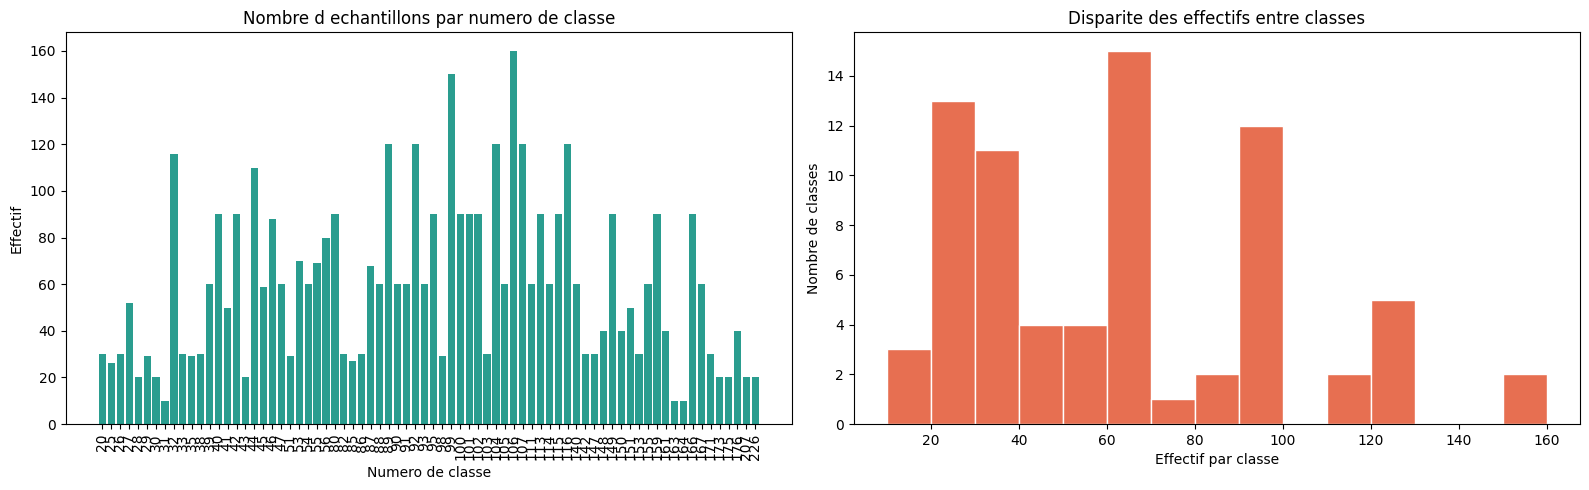

In [9]:
import matplotlib.pyplot as plt

class_counts = target.value_counts().sort_index()

min_count = int(class_counts.min())
max_count = int(class_counts.max())
mean_count = float(class_counts.mean())
std_count = float(class_counts.std(ddof=0))
imbalance_ratio = max_count / max(min_count, 1)
cv = std_count / mean_count if mean_count > 0 else np.nan

print(f"Nombre de classes: {class_counts.shape[0]}")
print(f"Min/Max par classe: {min_count} / {max_count}")
print(f"Ratio de disparite (max/min): {imbalance_ratio:.2f}")
print(f"Coefficient de variation: {cv:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(class_counts.index.astype(str), class_counts.values, color="#2a9d8f")
axes[0].set_title("Nombre d echantillons par numero de classe")
axes[0].set_xlabel("Numero de classe")
axes[0].set_ylabel("Effectif")
axes[0].tick_params(axis="x", labelrotation=90)

axes[1].hist(class_counts.values, bins=15, color="#e76f51", edgecolor="white")
axes[1].set_title("Disparite des effectifs entre classes")
axes[1].set_xlabel("Effectif par classe")
axes[1].set_ylabel("Nombre de classes")

plt.tight_layout()
plt.show()

Pour l'instant on fait une classif basique mais on pourrait aussi essayer en normalisant standars scaler ne regle pas le desiquilibre de classe. Donc deuxieme pîste d'amélioratino


In [10]:
# Verification: class_id est cree a partir de la position voxel (i, j, k)
check_cols = ["xyz","x", "y", "z", "i", "j", "k", "class_id"]
display(df[check_cols].head(10))

labels_uniques = np.sort(df["class_id"].unique())
print("Nombre de labels uniques:", len(labels_uniques))
print("Premiers labels tries:", labels_uniques[:10])



,xyz,x,y,z,i,j,k,class_id
0,1.82__2.51__0.05,1.82,2.51,0.05,1,2,0,25
1,10.1__3.82__1.29,10.10,3.82,1.29,10,3,1,106
2,10.34__3.33__0.05,10.34,3.33,0.05,10,3,0,46
3,10.51__3.26__0.05,10.51,3.26,0.05,10,3,0,46
4,10.71__3.92__1.57,10.71,3.92,1.57,10,3,1,106
5,10.72__3.5__0.05,10.72,3.50,0.05,10,3,0,46
6,10.79__3.89__1.57,10.79,3.89,1.57,10,3,1,106
7,10.98__1.98__1.1300000000000001,10.98,1.98,1.13,10,1,1,82
8,11.01__3.87__1.08,11.01,3.87,1.08,11,3,1,107
9,11.16__3.95__1.07,11.16,3.95,1.07,11,3,1,107


Nombre de labels uniques: 74
Premiers labels tries: [20 25 26 27 28 29 30 31 32 33]


In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)


print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (3528, 48)
Test: (883, 48)


In [12]:
from sklearn.model_selection import GroupShuffleSplit

# Anti-fuite: on separe par groupe de position xyz
groups = df.loc[X_small.index, "xyz"].astype(str) if "xyz" in df.columns else df.loc[X.index].index.astype(str)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_small, target, groups=groups))

X_train_small, X_test_small = X_small.iloc[train_idx], X_small.iloc[test_idx]
y_train_small, y_test_small = target.iloc[train_idx], target.iloc[test_idx]

print("Train:", X_train_small.shape)
print("Test:", X_test_small.shape)
print("Groupes train:", groups.iloc[train_idx].nunique())
print("Groupes test:", groups.iloc[test_idx].nunique())

Train: (3529, 48)
Test: (882, 48)
Groupes train: 355
Groupes test: 89


In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

num_features = X_train_scaled.shape[1]
num_classes = target.nunique()

print("num_features =", num_features)
print("num_classes =", num_classes)

num_features = 48
num_classes = 74


## Partie 1 - Regression logistique multiclasse basique
Modele baseline.

In [14]:
from sklearn.linear_model import LogisticRegression

RLog = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

RLog.fit(X_train_scaled, y_train)

y_pred = RLog.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred)

print("Logistic Regression accuracy:", acc_lr)

Logistic Regression accuracy: 0.2287655719139298


In [15]:
def decode_class_id(class_id, Nx, Ny):
    k = class_id // (Nx * Ny)
    remainder = class_id % (Nx * Ny)

    j = remainder // Nx
    i = remainder % Nx

    return i, j, k

In [16]:

def voxel_center(class_id, Nx, Ny, h):
    i, j, k = decode_class_id(class_id, Nx, Ny)

    x = (i + 0.5) * h
    y = (j + 0.5) * h
    z = (k + 0.5) * h

    return np.array([x, y, z])

In [17]:
metrics_lr = calculate_localization_errors(
    y_pred_cv=y_pred,
    df=df,
    X_test=X_test,
    Nx=Nx,
    Ny=Ny,
    h=h,
    voxel_center=voxel_center,
    random_seed=42
)

predA3 = metrics_lr["predicted_coords"]
xyz_test = metrics_lr["true_coords"]
errors = np.linalg.norm(xyz_test - predA3, axis=1)
rmse = float(metrics_lr["rmse"])

print("Erreur moyenne :", metrics_lr["mean_error"])
print("RMSE :", rmse)
print("Erreur mediane :", metrics_lr["median_error"])
print("Erreur max :", metrics_lr["max_error"])

Erreur moyenne : 1.4325717662878115
RMSE : 1.7899816837292135
Erreur mediane : 1.213672113875902
Erreur max : 7.957047191012505


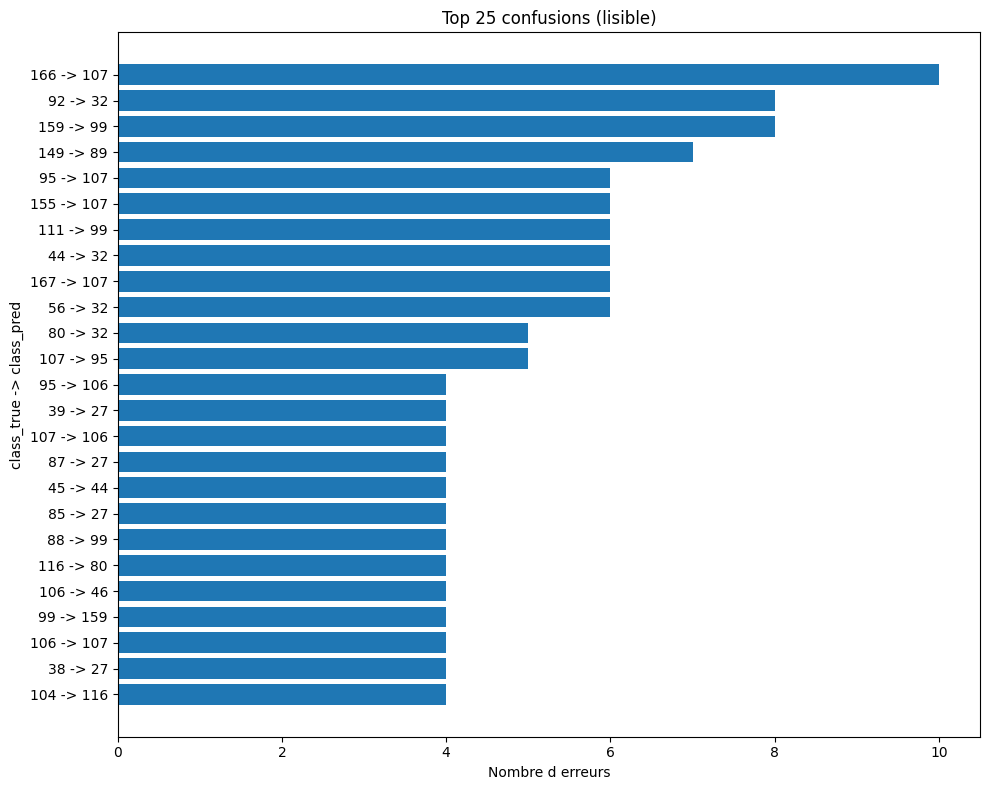

In [18]:
y_true = np.asarray(y_test).astype(int)
y_hat = np.asarray(y_pred).astype(int)

if y_true.shape[0] != y_hat.shape[0]:
    raise ValueError("y_test et y_pred n ont pas la meme taille.")

class_errors = pd.DataFrame({
    "class_true": y_true,
    "class_pred": y_hat,
})
class_errors = class_errors[class_errors["class_true"] != class_errors["class_pred"]].copy()

if class_errors.empty:
    print("Aucune erreur de class_id a afficher.")
else:
    confusion_err = (
        class_errors.groupby(["class_true", "class_pred"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    # 1) Top confusions en barres horizontales (plus lisible)
    top_n = 25
    top_err = confusion_err.head(top_n).copy()
    top_err["pair"] = top_err["class_true"].astype(str) + " -> " + top_err["class_pred"].astype(str)
    top_err = top_err.sort_values("count", ascending=True)

    plt.figure(figsize=(10, 8))
    plt.barh(top_err["pair"], top_err["count"])
    plt.title(f"Top {top_n} confusions (lisible)")
    plt.xlabel("Nombre d erreurs")
    plt.ylabel("class_true -> class_pred")
    plt.tight_layout()
    plt.show()

In [19]:
df_diff, df_diff_1m, stats_diff_1m = analyze_prediction_errors(
    y_test=y_test,
    y_pred_cv=y_pred,
    xyz_test_cv=xyz_test,
    predA3_cv=predA3,
    threshold=1.0,
    random_seed=42
)

print("Nombre total de lignes:", len(df_diff))
print("Nombre d'erreurs > 1 m:", len(df_diff_1m))

display(df_diff_1m.head(20))

print(stats_diff_1m)

Nombre total de lignes: 883
Nombre d'erreurs > 1 m: 547


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
0,91,32,7.86,2.99,1.10,8.5,2.5,0.5,0.64,-0.49,-0.60,1.004838
1,105,44,9.30,3.70,1.67,8.5,3.5,0.5,-0.80,-0.20,-1.17,1.431398
2,95,106,11.59,2.78,1.28,10.5,3.5,1.5,-1.09,0.72,0.22,1.324726
3,100,113,4.52,3.67,1.34,5.5,4.5,1.5,0.98,0.83,0.16,1.294179
4,53,42,5.55,4.09,0.42,6.5,3.5,0.5,0.95,-0.59,0.08,1.121160
7,101,111,5.04,3.83,1.05,3.5,4.5,1.5,-1.54,0.67,0.45,1.738678
8,93,104,9.57,2.71,1.96,8.5,3.5,1.5,-1.07,0.79,-0.46,1.407338
9,114,161,6.55,4.02,1.86,5.5,3.5,2.5,-1.05,-0.52,0.64,1.335103
10,47,107,11.23,3.36,0.37,11.5,3.5,1.5,0.27,0.14,1.13,1.170214
11,111,99,3.20,4.47,1.67,3.5,3.5,1.5,0.30,-0.97,-0.17,1.029466


       class_id_true  class_id_pred          dx          dy          dz  \
count     547.000000     547.000000  547.000000  547.000000  547.000000   
mean       96.857404      83.418647   -0.246508   -0.206782   -0.105631   
std        44.641036      41.817130    1.689315    0.993496    0.993531   
min        20.000000      20.000000   -7.690000   -3.020000   -3.040000   
25%        54.000000      40.000000   -0.990000   -0.950000   -0.855000   
50%        99.000000      92.000000    0.000000   -0.210000   -0.170000   
75%       116.000000     106.000000    0.775000    0.560000    0.480000   
max       226.000000     207.000000    4.300000    2.980000    2.450000   

         distance  
count  547.000000  
mean     1.955642  
std      1.054172  
min      1.001199  
25%      1.302497  
50%      1.658131  
75%      2.222363  
max      7.957047  


faudrait dig sur pq cette data donne ces erreurs maisjsp cmt faire 

On réessaie le même modèle mais cette fois ci avec X small


In [20]:
scaler = StandardScaler()

X_train_small_scaled = scaler.fit_transform(X_train_small)
X_test_small_scaled = scaler.transform(X_test_small)

num_features = X_train_small_scaled.shape[1]
num_classes = target.nunique()

print("num_features =", num_features)
print("num_classes =", num_classes)

num_features = 48
num_classes = 74


In [21]:
from sklearn.linear_model import LogisticRegression

RLog = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    random_state=42
)

RLog.fit(X_train_small_scaled, y_train_small)

y_pred = RLog.predict(X_test_small_scaled)
acc_lr = accuracy_score(y_test_small, y_pred)

print("Logistic Regression accuracy:", acc_lr)

Logistic Regression accuracy: 0.1473922902494331


aucun interet de continuer au vu de l'accuracy je pense.

## Partie 2 - Limitation de l eparpillement des classes
Reduction des classes surrepresentees; impact faible observe.

In [22]:
# Proportion de chaque class_id dans un DataFrame
df_prop_class = (
    df["class_id"]
    .value_counts()
    .rename_axis("class_id")
    .reset_index()
    .sort_values("class_id")
    .reset_index(drop=True)
)

print("Nombre de classes:", df_prop_class.shape[0])

display(df_prop_class.max())
mean = df_prop_class["class_id"].mean()
print("Moyenne:", mean)


Nombre de classes: 74


class_id    226
count       160
dtype: int64

Moyenne: 96.01351351351352


In [23]:
df_prop_class = (
    df["class_id"]
    .value_counts()
    .rename_axis("class_id")
    .reset_index(name="count")
)

print("Nombre de classes:", df_prop_class.shape[0])

# afficher les classes les plus représentées
display(df_prop_class.sort_values("count", ascending=True).head(20))

Nombre de classes: 74


,class_id,count
72,163,10
73,164,10
71,31,10
65,43,20
64,30,20
66,173,20
68,207,20
67,28,20
69,226,20
70,175,20


## Partie 3 - Regression logistique avec balanced
Test avec class_weight="balanced" pour compenser le desequilibre.

In [24]:
from sklearn.linear_model import LogisticRegression

RLog_balenced = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

RLog_balenced.fit(X_train_scaled, y_train)

y_pred_balenced = RLog_balenced.predict(X_test_scaled)
acc_lr_balenced = accuracy_score(y_test, y_pred_balenced)

print("Logistic Regression accuracy:", acc_lr_balenced)

Logistic Regression accuracy: 0.16534541336353342


etonnament l'accuracy descends ... néanmoins ce n'est pas une metrics fiable on va tester d'avantage.


In [25]:
metrics_balanced = calculate_localization_errors(
    y_pred_cv=y_pred_balenced,
    df=df,
    X_test=X_test,
    Nx=Nx,
    Ny=Ny,
    h=h,
    voxel_center=voxel_center,
    random_seed=42
)

predA3_balenced = metrics_balanced["predicted_coords"]
xyz_test_balenced = metrics_balanced["true_coords"]
errors = np.linalg.norm(xyz_test_balenced - predA3_balenced, axis=1)
rmse = float(metrics_balanced["rmse"])

print("Erreur moyenne :", metrics_balanced["mean_error"])
print("RMSE :", rmse)
print("Erreur mediane :", metrics_balanced["median_error"])
print("Erreur max :", metrics_balanced["max_error"])

Erreur moyenne : 1.6975166327277453
RMSE : 2.1856378726889494
Erreur mediane : 1.4075865870347017
Erreur max : 9.903262088827095


In [26]:
df_diff_balenced, df_diff_balenced_1p7m, stats_balanced_3m = analyze_prediction_errors(
    y_test=y_test,
    y_pred_cv=y_pred_balenced,
    xyz_test_cv=xyz_test_balenced,
    predA3_cv=predA3_balenced,
    threshold=3.0,
    random_seed=42
)

print("Nombre total de lignes:", len(df_diff_balenced))
print("Nombre d erreurs > 1.7 m:", len(df_diff_balenced_1p7m))

display(df_diff_balenced_1p7m.head(20))

print(stats_balanced_3m)

Nombre total de lignes: 883
Nombre d erreurs > 1.7 m: 79


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
38,176,142,8.56,4.52,2.12,10.5,1.5,2.5,1.94,-3.02,0.38,3.609487
54,29,25,5.44,2.66,0.05,1.5,2.5,0.5,-3.94,-0.16,0.45,3.968841
59,56,80,8.56,4.52,0.83,8.5,1.5,1.5,-0.06,-3.02,0.67,3.094010
62,32,25,8.56,2.48,0.70,1.5,2.5,0.5,-7.06,0.02,-0.20,7.062861
95,166,25,10.71,3.92,2.86,1.5,2.5,0.5,-9.21,-1.42,-2.36,9.613017
99,39,175,3.76,3.33,0.37,7.5,4.5,2.5,3.74,1.17,2.13,4.460202
100,102,111,6.83,3.36,1.02,3.5,4.5,1.5,-3.33,1.14,0.48,3.552309
109,95,32,11.19,2.26,1.88,8.5,2.5,0.5,-2.69,0.24,-1.38,3.032837
117,40,163,4.04,3.21,0.37,7.5,3.5,2.5,3.46,0.29,2.13,4.073402
118,155,25,11.19,2.26,2.53,1.5,2.5,0.5,-9.69,0.24,-2.03,9.903262


       class_id_true  class_id_pred         dx         dy         dz  \
count      79.000000      79.000000  79.000000  79.000000  79.000000   
mean       83.594937      71.556962  -2.906962  -0.801899   0.120633   
std        45.298304      60.688728   4.118723   1.137356   1.376463   
min        29.000000      20.000000  -9.730000  -3.020000  -3.040000   
25%        42.000000      25.000000  -6.295000  -1.435000  -0.640000   
50%        91.000000      32.000000  -3.220000  -0.840000   0.130000   
75%       107.000000     101.000000  -0.060000   0.010000   0.540000   
max       207.000000     207.000000   5.460000   1.630000   3.450000   

        distance  
count  79.000000  
mean    4.954087  
std     2.125859  
min     3.020662  
25%     3.338666  
50%     3.968841  
75%     6.475271  
max     9.903262  


on observe pas des résultat proprement meilleurs, néanmoins on peut également tester d'autre méthode.

## Partie 4 - Regression logistique avec CV en 5 folds
Evaluation par validation croisee (5 folds).

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

RLog_cv = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    random_state=53
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(RLog_cv, X_train, y_train, cv=cv)

print("CV accuracy scores:", cv_scores)
print("CV mean accuracy:", cv_scores.mean())

# entrainement final
RLog_cv.fit(X_train, y_train)

y_pred_cv = RLog_cv.predict(X_test)
acc_lr_cv = accuracy_score(y_test, y_pred_cv)

print("Test accuracy:", acc_lr_cv)

CV accuracy scores: [0.21104816 0.16855524 0.21954674 0.18865248 0.2       ]
CV mean accuracy: 0.1975605247825126
Test accuracy: 0.21630804077010193


In [28]:
coef_df = pd.DataFrame(
    RLog_cv.coef_,
    columns=X_train.columns
)
coef_df.max()

max__rssi__24.0__041A9F60__NONE          1.864131
max__rssi__24.0__041A9F61__NONE          3.545273
max__rssi__24.0__0F173B12__NONE          2.329445
max__rssi__24.0__0F173B13__NONE          3.267427
max__rssi__24.0__PORT_1__NONE            1.738862
max__rssi__24.0__PORT_2__NONE            1.751212
max__rssi__24.0__PORT_3__NONE            1.809021
max__rssi__24.0__PORT_4__NONE            2.527376
max__rssi__27.0__041A9F60__NONE          2.222480
max__rssi__27.0__041A9F61__NONE          2.852494
max__rssi__27.0__0F173B12__NONE          2.608585
max__rssi__27.0__0F173B13__NONE          2.224404
max__rssi__27.0__PORT_1__NONE            1.304684
max__rssi__27.0__PORT_2__NONE            1.295144
max__rssi__27.0__PORT_3__NONE            1.854670
max__rssi__27.0__PORT_4__NONE            1.813686
max__rssi__31.5__041A9F60__NONE          2.185952
max__rssi__31.5__041A9F61__NONE          1.854170
max__rssi__31.5__0F173B12__NONE          1.613643
max__rssi__31.5__0F173B13__NONE          2.230270


In [29]:
metrics_cv = calculate_localization_errors(
    y_pred_cv=y_pred_cv,
    df=df,
    X_test=X_test,
    Nx=Nx,
    Ny=Ny,
    h=h,
    voxel_center=voxel_center,
    random_seed=42
)

predA3_cv = metrics_cv["predicted_coords"]
xyz_test_cv = metrics_cv["true_coords"]
errors = np.linalg.norm(xyz_test_cv - predA3_cv, axis=1)
rmse_cv = float(metrics_cv["rmse"])

print("Erreur moyenne :", metrics_cv["mean_error"])
print("RMSE :", rmse_cv)
print("Erreur mediane :", metrics_cv["median_error"])
print("Erreur max :", metrics_cv["max_error"])

Erreur moyenne : 1.422352213552276
RMSE : 1.7869548682099536
Erreur mediane : 1.197747886660628
Erreur max : 7.957047191012505


In [30]:
df_diff_cv, df_diff_cv_1p3m, stats_cv_1p3m = analyze_prediction_errors(
    y_test=y_test,
    y_pred_cv=y_pred_cv,
    xyz_test_cv=xyz_test_cv,
    predA3_cv=predA3_cv,
    threshold=1.3,
    random_seed=42
)

print("Nombre total de lignes:", len(df_diff_cv))
print("Nombre d erreurs > 1.3 m:", len(df_diff_cv_1p3m))

display(df_diff_cv_1p3m.head(20))

print(stats_cv_1p3m)

Nombre total de lignes: 883
Nombre d erreurs > 1.3 m: 403


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
1,105,44,9.30,3.70,1.67,8.5,3.5,0.5,-0.80,-0.20,-1.17,1.431398
2,95,106,11.59,2.78,1.28,10.5,3.5,1.5,-1.09,0.72,0.22,1.324726
7,101,99,5.04,3.83,1.05,3.5,3.5,1.5,-1.54,-0.33,0.45,1.637987
10,47,106,11.23,3.36,0.37,10.5,3.5,1.5,-0.73,0.14,1.13,1.352553
12,151,44,7.86,2.99,2.40,8.5,3.5,0.5,0.64,0.51,-1.90,2.068744
13,46,107,10.51,3.26,0.37,11.5,3.5,1.5,0.99,0.24,1.13,1.521381
16,90,40,6.34,2.69,1.43,4.5,3.5,0.5,-1.84,0.81,-0.93,2.215085
17,102,40,6.16,3.97,1.34,4.5,3.5,0.5,-1.66,-0.47,-0.84,1.918880
25,113,40,5.49,4.30,1.67,4.5,3.5,0.5,-0.99,-0.80,-1.17,1.728872
26,102,40,6.83,3.36,1.67,4.5,3.5,0.5,-2.33,0.14,-1.17,2.611015


       class_id_true  class_id_pred          dx          dy          dz  \
count      403.00000     403.000000  403.000000  403.000000  403.000000   
mean        98.25062      82.238213   -0.382208   -0.088486   -0.176774   
std         46.68508      35.494696    1.988644    1.076875    0.958233   
min         20.00000      20.000000   -7.730000   -3.020000   -3.040000   
25%         54.00000      42.000000   -1.360000   -0.800000   -0.925000   
50%        100.00000      99.000000   -0.060000   -0.090000   -0.200000   
75%        141.00000     106.000000    0.790000    0.770000    0.480000   
max        226.00000     176.000000    3.980000    2.980000    2.450000   

         distance  
count  403.000000  
mean     2.222171  
std      1.125997  
min      1.300500  
25%      1.547126  
50%      1.858629  
75%      2.445328  
max      7.957047  


In [31]:
print(*X_train.columns, sep="\n")

max__rssi__24.0__041A9F60__NONE
max__rssi__24.0__041A9F61__NONE
max__rssi__24.0__0F173B12__NONE
max__rssi__24.0__0F173B13__NONE
max__rssi__24.0__PORT_1__NONE
max__rssi__24.0__PORT_2__NONE
max__rssi__24.0__PORT_3__NONE
max__rssi__24.0__PORT_4__NONE
max__rssi__27.0__041A9F60__NONE
max__rssi__27.0__041A9F61__NONE
max__rssi__27.0__0F173B12__NONE
max__rssi__27.0__0F173B13__NONE
max__rssi__27.0__PORT_1__NONE
max__rssi__27.0__PORT_2__NONE
max__rssi__27.0__PORT_3__NONE
max__rssi__27.0__PORT_4__NONE
max__rssi__31.5__041A9F60__NONE
max__rssi__31.5__041A9F61__NONE
max__rssi__31.5__0F173B12__NONE
max__rssi__31.5__0F173B13__NONE
max__rssi__31.5__PORT_1__NONE
max__rssi__31.5__PORT_2__NONE
max__rssi__31.5__PORT_3__NONE
max__rssi__31.5__PORT_4__NONE
max__Delta_rssi__24.0__041A9F60__NONE
max__Delta_rssi__24.0__041A9F61__NONE
max__Delta_rssi__24.0__0F173B12__NONE
max__Delta_rssi__24.0__0F173B13__NONE
max__Delta_rssi__24.0__PORT_1__NONE
max__Delta_rssi__24.0__PORT_2__NONE
max__Delta_rssi__24.0__PORT_3__N

### Moyenne des probabilités pour améliorer la localisation

Actuellement, le modèle prédit un **voxel** via une régression logistique multinomiale.  
La position \((x,y,z)\) est ensuite obtenue en prenant **le centre du voxel le plus probable (argmax)**.

Cependant, l’argmax utilise uniquement la classe la plus probable et **ignore l’information contenue dans le reste de la distribution de probabilités**.

L’idée est donc d’utiliser les probabilités prédites pour calculer **une moyenne pondérée des centres des voxels** :

$$
(\hat{x}, \hat{y}, \hat{z}) = \sum_{k} p_k \,(x_k, y_k, z_k)
$$

où :

- $p_k$ est la probabilité prédite pour le voxel $k$
- $(x_k, y_k, z_k)$ est le centre du voxel $k$

Cette approche permet de **réduire l’erreur de discrétisation liée aux voxels**.  
Si le modèle hésite entre plusieurs voxels voisins, la moyenne pondérée permet de prédire une position **intermédiaire**, souvent plus proche de la position réelle que celle obtenue avec l’argmax.

In [32]:
RLog_cv_mean = LogisticRegression(
    max_iter=3000,
    solver="lbfgs",
    random_state=53
)

folds = KFold(n_splits=8, shuffle=True, random_state=42)
cv_scores_mean = cross_val_score(RLog_cv, X_train_scaled, y_train, cv=folds)

print("CV accuracy scores:", cv_scores_mean)
print("CV mean accuracy:", cv_scores_mean.mean())

# entraînement final
RLog_cv_mean.fit(X_train_scaled, y_train)

distrib_proba = RLog_cv_mean.predict_proba(X_test_scaled)




CV accuracy scores: [0.17913832 0.1814059  0.20861678 0.19501134 0.22675737 0.21995465
 0.17913832 0.17687075]
CV mean accuracy: 0.19586167800453516


In [33]:
classes = RLog_cv_mean.classes_.astype(float)   # ex: [0, 1, 2, ...] ou labels réels
classes.shape

(74,)

In [34]:
distrib_proba[1].shape

(74,)

In [35]:
y_pred_cv_mean = []
n = len(distrib_proba)

for i in range(n):
    a = np.sum(distrib_proba[i] * classes)
    y_pred_cv_mean.append(a)

centers = np.array([voxel_center(int(c), Nx, Ny, h) for c in classes], dtype=float) # on construit la table des centres de chaques voxels
predA3_cv_mean = distrib_proba @ centers # on fait le produit matriciel entre les proba et les centres pour obtenir la position prédite en continu (non discrète)


predA3_cv_mean.shape


(883, 3)

In [36]:

true_coords = df.loc[X_test.index, ["x", "y", "z"]].to_numpy(dtype=float)


errors = np.linalg.norm(true_coords - predA3_cv_mean, axis=1)
rmse = float(np.sqrt(np.mean(errors ** 2)))

print("Erreur moyenne :", errors.mean())
print("RMSE :", rmse)
print("Erreur mediane :", np.median(errors))
print("Erreur max :", errors.max())

Erreur moyenne : 1.3707700692454725
RMSE : 1.5949859061944838
Erreur mediane : 1.2014782366472414
Erreur max : 5.048822662257808


In [37]:
rows_diff = []

for class_true, class_pred_mean, xyz_true, xyz_pred_cv_mean in zip(
    np.asarray(y_test).astype(int),
    np.asarray(y_pred_cv_mean, dtype=float),
    xyz_test,
    predA3_cv_mean
):
    dx = float(xyz_pred_cv_mean[0] - xyz_true[0])
    dy = float(xyz_pred_cv_mean[1] - xyz_true[1])
    dz = float(xyz_pred_cv_mean[2] - xyz_true[2])
    dist = float(np.linalg.norm([dx, dy, dz]))

    rows_diff.append({
        "class_id_true": int(class_true),
        "class_id_pred_mean": float(class_pred_mean),
        "x_true": float(xyz_true[0]),
        "y_true": float(xyz_true[1]),
        "z_true": float(xyz_true[2]),
        "x_pred": float(xyz_pred_cv_mean[0]),
        "y_pred": float(xyz_pred_cv_mean[1]),
        "z_pred": float(xyz_pred_cv_mean[2]),
        "dx": dx,
        "dy": dy,
        "dz": dz,
        "distance": dist
    })

df_diff_cv_mean = pd.DataFrame(rows_diff)

print("Nombre total de lignes:", len(df_diff_cv_mean))

df_diff_cv_mean_1m = df_diff_cv_mean[df_diff_cv_mean["distance"] > 2]
print("Nombre d erreurs > 1 m:", len(df_diff_cv_mean_1m))

display(df_diff_cv_mean_1m.head(20))

print(df_diff_cv_mean_1m[[
    "class_id_true",
    "class_id_pred_mean",
    "dx",
    "dy",
    "dz",
    "distance"
]].describe())

Nombre total de lignes: 883
Nombre d erreurs > 1 m: 175


,class_id_true,class_id_pred_mean,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
5,27,79.659517,3.36,2.09,0.70,5.887309,3.039498,1.229971,2.527309,0.949498,0.529971,2.751310
13,46,83.575102,10.51,3.26,0.37,7.175524,3.076849,1.266290,-3.334476,-0.183151,0.896290,3.457688
27,25,80.724876,1.82,2.51,0.37,5.568751,3.145011,1.231933,3.748751,0.635011,0.861933,3.898629
31,142,99.860333,10.98,1.98,2.42,9.345103,2.947300,1.527461,-1.634897,0.967300,-0.892539,2.098853
40,86,86.718831,2.88,2.90,1.02,5.051463,3.273511,1.314754,2.171463,0.373511,0.294754,2.222980
55,20,101.938361,8.57,1.92,0.80,8.499999,3.856483,1.394343,-0.070001,1.936483,0.594343,2.026847
59,56,90.477818,8.56,4.52,0.83,8.500369,2.373927,1.499839,-0.059631,-2.146073,0.669839,2.248971
64,25,78.178599,1.82,2.51,0.37,5.044362,3.090781,1.209081,3.224362,0.580781,0.839081,3.381992
65,56,36.437021,8.56,4.52,0.83,8.505500,2.527387,0.568381,-0.054500,-1.992613,-0.261619,2.010453
73,42,84.309431,6.68,3.78,0.05,4.996791,3.353894,1.259432,-1.683209,-0.426106,1.209432,2.116007


       class_id_true  class_id_pred_mean          dx          dy          dz  \
count     175.000000          175.000000  175.000000  175.000000  175.000000   
mean       89.160000           88.036126    0.146361   -0.008933    0.093157   
std        51.008987           16.449511    2.434055    0.881795    0.947593   
min        20.000000           20.096587   -3.989689   -3.019425   -2.291237   
25%        41.500000           79.737225   -2.044736   -0.713056   -0.675290   
50%        87.000000           84.027972   -0.058718    0.050537    0.216734   
75%       116.000000           94.370768    2.325585    0.732849    0.857338   
max       226.000000          175.689726    4.954631    1.936483    2.115209   

         distance  
count  175.000000  
mean     2.679027  
std      0.641902  
min      2.000676  
25%      2.173525  
50%      2.522825  
75%      2.991587  
max      5.048823  


In [38]:
n = min(len(df_diff_cv_mean), len(df_diff_cv_mean))

left = df_diff_cv[["class_id_true", "class_id_pred", "distance"]].iloc[:n].reset_index(drop=False)
right = df_diff_cv_mean[[ "class_id_pred_mean", "distance"]].iloc[:n].reset_index(drop=True)

comp = pd.DataFrame({
    "class_id_true": left["class_id_true"].astype(int),
    "class_id_pred_cv": left["class_id_pred"].astype(int),
    "class_id_pred_cv_mean": right["class_id_pred_mean"].astype(float),
    "distance_cv": left["distance"].astype(float),
    "distance_cv_mean": right["distance"].astype(float),
})

comp["delta_class_id_pred"] = comp["class_id_pred_cv"] - comp["class_id_pred_cv_mean"]
comp["delta_distance"] = comp["distance_cv"] - comp["distance_cv_mean"]

# Garder uniquement les lignes differentes entre les deux approches
tol = 1e-12
mask_diff = (
    (comp["delta_class_id_pred"].abs() > tol)
    | (comp["delta_distance"].abs() > tol)
)

df_comp = comp.loc[mask_diff].reset_index(drop=True)

print("Lignes comparees:", len(comp))
print("Lignes differentes:", len(df_comp))
display(df_comp.head(20))
print(df_comp[["delta_class_id_pred", "delta_distance"]].describe())

Lignes comparees: 883
Lignes differentes: 883


,class_id_true,class_id_pred_cv,class_id_pred_cv_mean,distance_cv,distance_cv_mean,delta_class_id_pred,delta_distance
0,91,32,80.967446,1.004838,0.574284,-48.967446,0.430554
1,105,44,72.090682,1.431398,1.005409,-28.090682,0.425989
2,95,106,95.667543,1.324726,1.466930,10.332457,-0.142204
3,100,113,106.639117,1.294179,1.279074,6.360883,0.015105
4,53,42,81.947391,1.121160,1.267050,-39.947391,-0.145890
5,27,27,79.659517,0.477179,2.751310,-52.659517,-2.274131
6,149,89,91.369996,0.742226,0.704653,-2.369996,0.037574
7,101,99,93.677153,1.637987,1.320697,5.322847,0.317290
8,93,92,90.825677,1.183469,1.900738,1.174323,-0.717269
9,114,114,137.495445,0.602080,0.557351,-23.495445,0.044729


       delta_class_id_pred  delta_distance
count           883.000000      883.000000
mean             -9.620041        0.051582
std              26.040024        1.031266
min             -93.907043       -3.363771
25%             -31.692340       -0.398956
50%              -2.747552        0.040779
75%               8.874512        0.479275
max              72.600593        4.480296


### Decision Tree :
Je pense qu'il peut être judicieux de vraiment tester les arbres de décision. dans un premier temps on a vu que Extra Treefonctionnait donc c une voix encouragente  et je pense que pour comprendre mieux comme les datas sont séparés faire ce type d'algo est bénéfique pour mieux comprendre et intérpreter les erreurs

première implémentation naïves:

In [39]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(criterion="entropy", random_state=42)
model_dt.fit(X_train_scaled, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [40]:


print('Profondeur :', model_dt.get_depth())
print('Nombre de noeuds :', model_dt.tree_.node_count)
print('Nombre de feuilles :', model_dt.get_n_leaves())
print('Critere par defaut :', model_dt.criterion)



Profondeur : 17
Nombre de noeuds : 3835
Nombre de feuilles : 1918
Critere par defaut : entropy


In [41]:
from sklearn.model_selection import cross_validate
cv_resultas = cross_validate(model_dt, X, y, cv=5, return_train_score =True)
cv_resultas

{'fit_time': array([0.80330944, 0.76840925, 0.75241637, 0.74781632, 0.8036387 ]),
 'score_time': array([0.00099897, 0.00100279, 0.00099969, 0.00199723, 0.00300026]),
 'test_score': array([0.10079275, 0.10997732, 0.11111111, 0.12585034, 0.09750567]),
 'train_score': array([1., 1., 1., 1., 1.])}

In [42]:
y_pred_DT = model_dt.predict(X_test_scaled)

Overfit réel : idée pruning?

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate

# 1. Définis et entraîne le modèle sur X_train
model_dt_max = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2
)
model_dt_max.fit(X_train_scaled, y_train)

# 2. Validation croisée sur X_train (pour évaluer la généralisation)
cv_results = cross_validate(
    model_dt_max,
    X_train_scaled,
    y_train,
    cv=5,
    return_train_score=True
)

# 3. Prédictions sur X_test (pour l'évaluation finale)
y_pred_DT = model_dt_max.predict(X_test_scaled)  # ✅ Ici, y_pred_DT contient les prédictions


In [44]:
cv_results

{'fit_time': array([0.69824958, 0.70426917, 0.73244667, 0.6636529 , 0.66507268]),
 'score_time': array([0.00100231, 0.00200033, 0.00100875, 0.00199962, 0.00099802]),
 'test_score': array([0.13739377, 0.1388102 , 0.10764873, 0.11347518, 0.1248227 ]),
 'train_score': array([0.58433735, 0.57937633, 0.61764706, 0.59298618, 0.57669146])}

In [45]:


print('Profondeur :', model_dt_max.get_depth())
print('Nombre de noeuds :', model_dt_max.tree_.node_count)
print('Nombre de feuilles :', model_dt_max.get_n_leaves())
print('Critere par defaut :', model_dt_max.criterion)



Profondeur : 10
Nombre de noeuds : 1287
Nombre de feuilles : 644
Critere par defaut : entropy


profondeur 19 vs 10


In [46]:
path = model_dt.cost_complexity_pruning_path(X_train_scaled, y_train)
ccp_alphas = path.ccp_alphas
print('Nombre de coefficients alpha :', len(ccp_alphas))
print('Premiers alphas :', ccp_alphas[:10])
print('alpha_0 :', ccp_alphas[0])

Nombre de coefficients alpha : 1874
Premiers alphas : [0.         0.00039043 0.00056689 0.00056689 0.00056689 0.00056689
 0.00056689 0.00056689 0.00056689 0.00056689]
alpha_0 : 0.0


In [47]:
cv_results = []
for alphas in ccp_alphas[::10]:
    model_dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alphas )
    score_alpha=cross_validate(model_dt_pruned, X_train_scaled, y_train, cv=5, return_train_score=True)
    cv_results.append(score_alpha['test_score'].mean())

cv_results


[np.float64(0.12329254816868582),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.12471420247925583),
 np.float64(0.

In [48]:
type(ccp_alphas)

numpy.ndarray

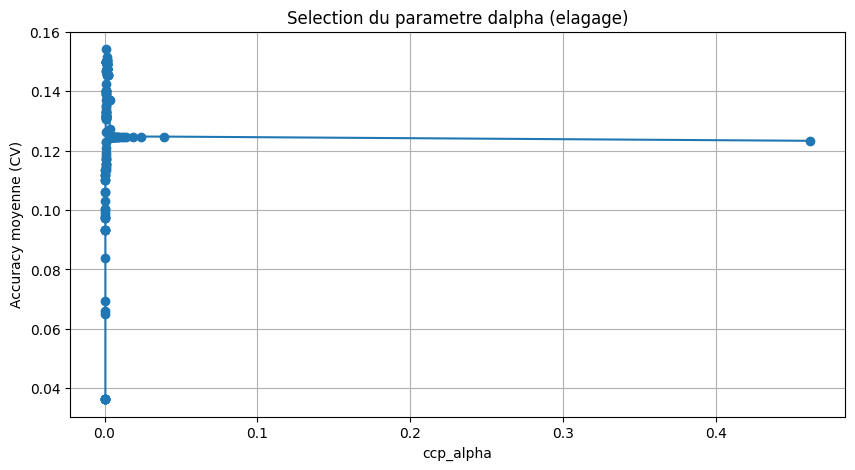

Meilleur alpha : 0.000567 avec CV accuracy : 0.1542


In [49]:
scores = list(score_alpha.values())
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas[::-10], cv_results[:], marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy moyenne (CV)')
plt.title('Selection du parametre dalpha (elagage)')
plt.grid(True)
plt.show()
best_idx = int(np.argmax(cv_results[:-1]))
best_alpha = ccp_alphas[best_idx]
best_cv_score = cv_results[best_idx]
print(f"Meilleur alpha : {best_alpha:.6f} avec CV accuracy : {best_cv_score:.4f}")



In [50]:
best_idx = int(np.argmax(cv_scores[:-1]))
best_alpha = ccp_alphas[best_idx]
best_cv_score = cv_scores[best_idx]

clf_prune = DecisionTreeClassifier(random_state=0, ccp_alpha=best_alpha)
clf_prune.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [51]:
y_pred_pruned = clf_prune.predict(X_test_scaled)
acc_pruned = accuracy_score(y_test, y_pred_pruned)
acc_pruned

c:\Users\AsgharAli Thomas\Documents\RFID2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.1245753114382786

In [52]:
metrics_dt_pruned = calculate_localization_errors(y_pred_pruned, df, X_test, Nx, Ny, h, voxel_center)
predA3 = metrics_dt_pruned["predicted_coords"]
xyz_test = metrics_dt_pruned["true_coords"]
errors = np.linalg.norm(xyz_test - predA3, axis=1)
rmse = float(metrics_dt_pruned["rmse"])
print("Erreur moyenne :", metrics_dt_pruned["mean_error"])
print("RMSE :", rmse)



Erreur moyenne : 2.6545826515376274
RMSE : 3.5468970057214686


In [53]:
df_diff_DT_pruned, df_diff_dt_pp, stats_balanced_pruned_3m= analyze_prediction_errors(y_test, y_pred_pruned, xyz_test, predA3_cv, threshold=2)

print("Nombre total de lignes:", len(df_diff_DT_pruned))
print("Nombre d erreurs > 1.7 m:", len(df_diff_dt_pp))

display(df_diff_dt_pp.head(20))

print(stats_balanced_pruned_3m)

Nombre total de lignes: 883
Nombre d erreurs > 1.7 m: 174


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
12,151,88,7.86,2.99,2.40,8.5,3.5,0.5,0.64,0.51,-1.90,2.068744
16,90,40,6.34,2.69,1.43,4.5,3.5,0.5,-1.84,0.81,-0.93,2.215085
26,102,47,6.83,3.36,1.67,4.5,3.5,0.5,-2.33,0.14,-1.17,2.611015
27,25,47,1.82,2.51,0.37,3.5,3.5,1.5,1.68,0.99,1.13,2.253752
28,88,149,4.41,2.39,1.71,6.5,4.5,1.5,2.09,2.11,-0.21,2.977297
38,176,47,8.56,4.52,2.12,11.5,3.5,1.5,2.94,-1.02,-0.62,3.173074
39,54,47,6.16,4.08,0.70,3.5,3.5,1.5,-2.66,-0.58,0.80,2.837605
48,151,47,7.40,2.87,2.84,8.5,2.5,0.5,1.10,-0.37,-2.34,2.611992
51,149,89,5.67,2.44,2.22,3.5,3.5,1.5,-2.17,1.06,-0.72,2.520099
52,56,56,8.87,4.79,0.05,8.5,2.5,0.5,-0.37,-2.29,0.45,2.362943


       class_id_true  class_id_pred          dx          dy          dz  \
count     174.000000     174.000000  174.000000  174.000000  174.000000   
mean       92.091954      70.655172   -0.923621   -0.339368   -0.150115   
std        44.555254      39.494882    2.739704    1.234137    1.002267   
min        20.000000      26.000000   -7.730000   -3.020000   -3.040000   
25%        53.250000      47.000000   -2.660000   -1.170000   -0.650000   
50%        92.000000      47.000000   -0.655000   -0.245000   -0.170000   
75%       116.000000      90.500000    1.630000    0.557500    0.480000   
max       207.000000     159.000000    3.980000    2.980000    2.450000   

         distance  
count  174.000000  
mean     3.047131  
std      1.300554  
min      2.002124  
25%      2.216662  
50%      2.615060  
75%      3.263237  
max      7.957047  


In [54]:
# Comparaison robuste et renommage des colonnes pour analyse DT_pruned
import pandas as pd
import numpy as np

# Vérification des colonnes et tailles
print("df_diff_dt_pp columns:", df_diff_dt_pp.columns)
print("df_diff_cv_mean columns:", df_diff_cv_mean.columns)
print("len(df_diff_dt_pp):", len(df_diff_dt_pp))
print("len(df_diff_cv_mean):", len(df_diff_cv_mean))

n = min(len(df_diff_dt_pp), len(df_diff_cv_mean))

left = df_diff_dt_pp[["class_id_true", "class_id_pred", "distance", "x_true", "y_true", "z_true", "x_pred", "y_pred", "z_pred"]].iloc[:n].reset_index(drop=True)
right = df_diff_cv_mean[["class_id_pred_mean", "x_pred", "y_pred", "z_pred"]].iloc[:n].reset_index(drop=True)

comp = pd.DataFrame({
    "class_id_true": left["class_id_true"].astype(int),
    "class_id_pred_dt_pruned": left["class_id_pred"].astype(int),
    "class_id_pred_cv_mean": right["class_id_pred_mean"].astype(int),
    "distance_dt_pruned": left["distance"].astype(float),
    "distance_cv": left["distance"].astype(float),  # distance_cv = distance_dt_pruned
    "x_true": left["x_true"].astype(float),
    "y_true": left["y_true"].astype(float),
    "z_true": left["z_true"].astype(float),
    "x_pred_dt_pruned": left["x_pred"].astype(float),
    "y_pred_dt_pruned": left["y_pred"].astype(float),
    "z_pred_dt_pruned": left["z_pred"].astype(float),
    "x_pred_cv_mean": right["x_pred"].astype(float),
    "y_pred_cv_mean": right["y_pred"].astype(float),
    "z_pred_cv_mean": right["z_pred"].astype(float),
})

# Calcul de la nouvelle delta_distance_cv (distance réelle - prédite par cv_mean)
comp["distance_cv_mean"] = np.linalg.norm(
    comp[["x_true", "y_true", "z_true"]].values - comp[["x_pred_cv_mean", "y_pred_cv_mean", "z_pred_cv_mean"]].values, axis=1
)

comp["delta_class_id_pred"] = comp["class_id_pred_dt_pruned"] - comp["class_id_pred_cv_mean"]
comp["delta_distance_cv"] = comp["distance_dt_pruned"] - comp["distance_cv_mean"]

# Filtrer uniquement les erreurs où la distance cv_mean > 1.5
comp_filtered = comp[comp["distance_cv_mean"] > 1.5].reset_index(drop=True)

tol = 1e-12
mask_diff = (
    (comp_filtered["delta_class_id_pred"].abs() > tol)
    | (comp_filtered["delta_distance_cv"].abs() > tol)
)

df_comp = comp_filtered.loc[mask_diff].reset_index(drop=True)

print("Lignes comparées (filtrées):", len(comp_filtered))
print("Lignes différentes:", len(df_comp))
display(df_comp.head(20))
print(df_comp[["delta_class_id_pred", "delta_distance_cv"]].describe())


df_diff_dt_pp columns: Index(['class_id_true', 'class_id_pred', 'x_true', 'y_true', 'z_true',
       'x_pred', 'y_pred', 'z_pred', 'dx', 'dy', 'dz', 'distance'],
      dtype='object')
df_diff_cv_mean columns: Index(['class_id_true', 'class_id_pred_mean', 'x_true', 'y_true', 'z_true',
       'x_pred', 'y_pred', 'z_pred', 'dx', 'dy', 'dz', 'distance'],
      dtype='object')
len(df_diff_dt_pp): 174
len(df_diff_cv_mean): 883
Lignes comparées (filtrées): 140
Lignes différentes: 140


,class_id_true,class_id_pred_dt_pruned,class_id_pred_cv_mean,distance_dt_pruned,distance_cv,x_true,y_true,z_true,x_pred_dt_pruned,y_pred_dt_pruned,z_pred_dt_pruned,x_pred_cv_mean,y_pred_cv_mean,z_pred_cv_mean,distance_cv_mean,delta_class_id_pred,delta_distance_cv
0,90,40,72,2.215085,2.215085,6.34,2.69,1.43,4.5,3.5,0.5,8.608885,3.594718,0.947420,2.489827,-32,-0.274742
1,102,47,95,2.611015,2.611015,6.83,3.36,1.67,4.5,3.5,0.5,10.170945,3.129180,1.407441,3.359186,-48,-0.748171
2,25,47,106,2.253752,2.253752,1.82,2.51,0.37,3.5,3.5,1.5,5.604705,4.342636,1.423713,4.335073,-59,-2.081320
3,88,149,81,2.977297,2.977297,4.41,2.39,1.71,6.5,4.5,1.5,6.267569,3.387052,1.192253,2.170884,68,0.806414
4,176,47,79,3.173074,3.173074,8.56,4.52,2.12,11.5,3.5,1.5,5.887309,3.039498,1.229971,3.182344,-32,-0.009270
5,54,47,91,2.837605,2.837605,6.16,4.08,0.70,3.5,3.5,1.5,5.500003,2.502422,1.539016,1.904809,-44,0.932796
6,151,47,93,2.611992,2.611992,7.40,2.87,2.84,8.5,2.5,0.5,3.778765,3.622222,1.382195,3.975472,-46,-1.363480
7,149,89,90,2.520099,2.520099,5.67,2.44,2.22,3.5,3.5,1.5,7.897005,3.346937,1.321090,2.567124,-1,-0.047025
8,56,56,137,2.362943,2.362943,8.87,4.79,0.05,8.5,2.5,0.5,6.036107,3.879191,2.023484,3.571437,-81,-1.208494
9,56,80,93,3.094010,3.094010,8.56,4.52,0.83,8.5,1.5,1.5,10.857795,3.436087,1.298676,2.583483,-13,0.510527


       delta_class_id_pred  delta_distance_cv
count           140.000000         140.000000
mean            -20.664286          -0.169515
std              43.991106           2.014979
min             -89.000000          -6.858152
25%             -53.000000          -1.214206
50%             -34.500000          -0.048206
75%               2.750000           0.868588
max              85.000000           5.457366


### Baaging 

In [55]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
param_grid_bag = {
    'n_estimators': [50, 100],
    'criterion': ['gini', 'entropy']
}

bag_model = RandomForestClassifier(
    random_state=0,
    bootstrap=True,
    oob_score=True,
    max_features=X_train_scaled.shape[1],
    n_jobs=-1
)

search_bag = GridSearchCV(
    estimator=bag_model,
    param_grid=param_grid_bag,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
search_bag.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [57]:
best_estimator_RF = search_bag.best_estimator_

print("Meilleurs hyperparamètres :", search_bag.best_params_)

Meilleurs hyperparamètres : {'criterion': 'gini', 'n_estimators': 100}


In [64]:

y_pred_RF = best_estimator_RF.predict(X_test_scaled)
metrics_dt_pruned = calculate_localization_errors(y_pred_RF, df, X_test, Nx, Ny, h, voxel_center)
pred_RF = metrics_dt_pruned["predicted_coords"]
xyz_test_rf = metrics_dt_pruned["true_coords"]
errors = np.linalg.norm(xyz_test_rf - pred_RF, axis=1)
rmse = float(metrics_dt_pruned["rmse"])
print("Erreur moyenne :", metrics_dt_pruned["mean_error"])
print("RMSE :", rmse)



Erreur moyenne : 2.529240033423723
RMSE : 3.5210968125439135


c:\Users\AsgharAli Thomas\Documents\RFID2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [65]:
df_diff_RF, df_diff_RF_pp, stats_balanced_RF_3m= analyze_prediction_errors(y_test, y_pred_pruned, xyz_test_rf, pred_RF, threshold=2)

print("Nombre total de lignes:", len(df_diff_RF))
print("Nombre d erreurs > 1.7 m:", len(df_diff_RF_pp))

display(df_diff_RF_pp.head(20))

print(stats_balanced_RF_3m)

Nombre total de lignes: 883
Nombre d erreurs > 1.7 m: 375


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
1,105,47,9.30,3.70,1.67,11.5,3.5,0.5,2.20,-0.20,-1.17,2.499780
4,53,47,5.55,4.09,0.42,11.5,3.5,0.5,5.95,-0.59,0.08,5.979716
5,27,47,3.36,2.09,0.70,11.5,3.5,0.5,8.14,1.41,-0.20,8.263637
8,93,27,9.57,2.71,1.96,2.5,2.5,0.5,-7.07,-0.21,-1.46,7.222230
12,151,88,7.86,2.99,2.40,7.5,4.5,0.5,-0.36,1.51,-1.90,2.453508
15,53,38,5.55,4.09,0.42,4.5,2.5,1.5,-1.05,-1.59,1.08,2.190205
16,90,40,6.34,2.69,1.43,1.5,2.5,1.5,-4.84,-0.19,0.07,4.844234
17,102,100,6.16,3.97,1.34,3.5,3.5,2.5,-2.66,-0.47,1.16,2.939745
23,55,142,7.73,4.45,0.70,11.5,3.5,1.5,3.77,-0.95,0.80,3.969307
25,113,47,5.49,4.30,1.67,1.5,2.5,0.5,-3.99,-1.80,-1.17,4.530894


       class_id_true  class_id_pred          dx          dy          dz  \
count     375.000000     375.000000  375.000000  375.000000  375.000000   
mean       87.997333      63.160000    2.747147   -0.158213   -0.226373   
std        46.653490      34.515764    4.181167    1.109704    1.131160   
min        25.000000      26.000000   -9.730000   -3.020000   -3.040000   
25%        42.500000      47.000000    0.035000   -0.950000   -0.885000   
50%        90.000000      47.000000    2.760000   -0.160000   -0.260000   
75%       114.500000      68.000000    6.260000    0.670000    0.450000   
max       226.000000     166.000000    9.680000    2.110000    2.450000   

         distance  
count  375.000000  
mean     4.642934  
std      2.454003  
min      2.013082  
25%      2.567880  
50%      3.461488  
75%      7.138825  
max      9.800582  


In [66]:
from sklearn.ensemble import ExtraTreesRegressor

model_ET = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42
)
model_ET.fit(X_train_scaled, y_train)
y_pred_ET = model_ET.predict(X_test_scaled)


In [72]:

metrics_dt_pruned = calculate_localization_errors(y_pred_ET, df, X_test, Nx, Ny, h, voxel_center)
pred_ET = metrics_dt_pruned["predicted_coords"]
xyz_test_ET = metrics_dt_pruned["true_coords"]
errors = np.linalg.norm(xyz_test_ET - pred_ET, axis=1)
rmse = float(metrics_dt_pruned["rmse"])
print("Erreur moyenne :", metrics_dt_pruned["mean_error"])
print("RMSE :", rmse)



Erreur moyenne : 4.1616746850609445
RMSE : 4.76063574130406


In [73]:
df_diff_ET, df_diff_ET_pp, stats_balanced_ET_3m= analyze_prediction_errors(y_test, y_pred_ET, xyz_test_ET, pred_ET, threshold=2)

print("Nombre total de lignes:", len(df_diff_ET))
print("Nombre d erreurs > 1.7 m:", len(df_diff_ET_pp))

display(df_diff_ET_pp.head(20))

print(stats_balanced_ET_3m)

Nombre total de lignes: 883
Nombre d erreurs > 1.7 m: 700


,class_id_true,class_id_pred,x_true,y_true,z_true,x_pred,y_pred,z_pred,dx,dy,dz,distance
0,91,60,7.86,2.99,1.10,0.94,0.5,1.5,-6.92,-2.49,0.40,7.365222
1,105,87,9.30,3.70,1.67,3.76,2.5,1.5,-5.54,-1.20,-0.17,5.671023
2,95,91,11.59,2.78,1.28,7.97,2.5,1.5,-3.62,-0.28,0.22,3.637472
4,53,70,5.55,4.09,0.42,10.86,0.5,1.5,5.31,-3.59,1.08,6.500046
6,149,95,5.67,2.44,2.22,11.56,2.5,1.5,5.89,0.06,-0.72,5.934147
8,93,87,9.57,2.71,1.96,3.80,2.5,1.5,-5.77,-0.21,-0.46,5.792115
9,114,123,6.55,4.02,1.86,4.23,0.5,2.5,-2.32,-3.52,0.64,4.264083
10,47,103,11.23,3.36,0.37,7.61,3.5,1.5,-3.62,0.14,1.13,3.794852
15,53,90,5.55,4.09,0.42,6.76,2.5,1.5,1.21,-1.59,1.08,2.271255
17,102,80,6.16,3.97,1.34,9.44,1.5,1.5,3.28,-2.47,0.16,4.109124


       class_id_true  class_id_pred          dx          dy          dz  \
count     700.000000     700.000000  700.000000  700.000000  700.000000   
mean       92.480000      92.420000   -0.810686   -0.618543    0.231371   
std        43.790578      21.150612    4.915280    1.512615    0.742817   
min        20.000000      33.000000  -10.660000   -4.290000   -3.040000   
25%        47.000000      80.000000   -4.777500   -1.800000   -0.192500   
50%        95.000000      94.000000   -2.045000   -0.585000    0.220000   
75%       114.000000     107.000000    3.420000    0.550000    0.800000   
max       226.000000     146.000000    9.500000    2.980000    2.450000   

         distance  
count  700.000000  
mean     4.892835  
std      2.029921  
min      2.008009  
25%      3.266465  
50%      4.417603  
75%      6.193586  
max     10.917234  
